<a href="https://colab.research.google.com/github/walmunsan-cloud/mini-api-tarefas/blob/main/C%C3%B3pia_de_AKCIT_GenAI_M10_Colab_Unidade_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

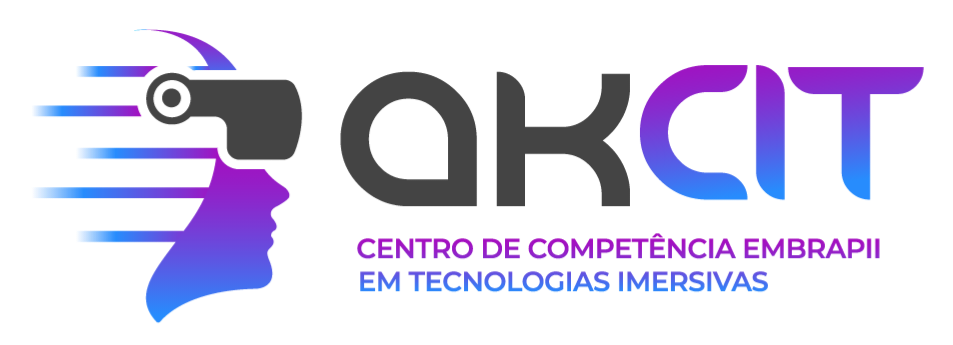


# Identificação

**Microcurso:** Arquiteturas neurais avançadas para IA generativa para visão computacional


**Docente:** M.Sc. Leon Sólon da Silva

## 📚 Introdução
Depois de AEs/VAEs (representações) e GANs/difusão (geração), esta unidade foca em **separar e recombinar conteúdo e estilo**:
- **Gatys et al.** mostram que camadas profundas de uma CNN (ex.: VGG) codificam conteúdo e que **matrizes de Gram** de ativações capturam estilo (texturas/paleta).
- Métodos **feed-forward** deslocam o custo para o treinamento e permitem estilização quase instantânea.
- **AdaIN** (Adaptive Instance Normalization) inspira estilização **arbitrária** ao alinhar estatísticas de features.
- Em paralelo, **image-to-image translation** (pix2pix/CycleGAN/difusão img2img) transforma um domínio em outro preservando estrutura global.


## 🎯 Objetivos de Aprendizagem
Ao final, você será capaz de:
1. Explicar o método de **Gatys** (2015/2016): conteúdo vs. estilo via VGG.
2. Executar **Neural Style Transfer** por otimização de pixels (PyTorch).
3. Discutir **feed-forward** (estilo único/multiestilo) e a ideia do **AdaIN**.
4. Aplicar **image-to-image translation** (ex.: stylization com difusão).
5. Ajustar pesos (conteúdo/estilo), camadas e hiperparâmetros, analisando trade-offs de qualidade/tempo.


## 🧠 Explicação Teórica
**Gatys (2015/2016):**
- Congela-se uma **VGG-19** pré-treinada (ImageNet).
- **Conteúdo**: ativações de uma camada profunda (ex.: conv4_2).
- **Estilo**: **matrizes de Gram** de várias camadas (conv1_1 … conv5_1).
- Otimiza-se a **imagem gerada** (não os pesos) para:
  - minimizar perda de conteúdo (MSE entre features da gerada vs. conteúdo);
  - minimizar perda de estilo (MSE entre Grams da gerada vs. estilo).
  



## 💻 Exemplos Práticos
**Neural Style Transfer (Gatys)** em PyTorch:
   - VGG-19 congelada
   - Perdas de conteúdo/estilo com matrizes de Gram
   - Otimização da imagem gerada
   
**CycleGAN pré-treinado (Horse → Zebra)** em PyTorch:
- Uso direto de pesos já treinados (`horse2zebra_pretrained`)
- Entrada personalizada (imagem de cavalo escolhida pelo usuário)
- Tradução não supervisionada entre domínios (cavalo ↔ zebra)
- Saída exibida lado a lado com a imagem original

## 📖 Referências
- GATYS, L. A.; ECKER, A. S.; BETHGE, M. (2015, 2016) – Neural Style Transfer.
- SIMONYAN, K.; ZISSERMAN, A. (2015) – Very Deep Convolutional Networks (VGG).
- JOHNSON, J.; ALAHI, A.; FEI-FEI, L. (2016) – Perceptual Losses / Fast Neural Style.
- ULYANOV, D. et al. (2016, 2017) – Texture Networks / Instance Norm / Multi-estilo.
- DUMOULIN, V.; SHLENS, J.; KUDLUR, M. (2017) – Learned Normalizations (multiestilo).
- HUANG, X.; BELONGIE, S. (2017) – **AdaIN**: Arbitrary Style Transfer in Real-Time.
- ZHU, J.-Y. et al. (2017) – CycleGAN (i2i sem pares).
- ISOLA, P. et al. (2017) – pix2pix (i2i com pares).


In [ ]:
# ======================================================
# Setup: imports, device, utilitários
# ======================================================

# PyTorch: base para redes neurais, treinamento, otimização
import torch, torch.nn as nn, torch.optim as optim

# Torchvision: modelos pré-treinados (ex.: VGG-19), transformações de imagens
import torchvision.models as models
import torchvision.transforms as T

# Matplotlib + NumPy: exibição e manipulação numérica de imagens
import matplotlib.pyplot as plt
import numpy as np

# PIL: abrir e salvar imagens
from PIL import Image

# BytesIO + requests: baixar imagens da internet em memória
from io import BytesIO
import requests

# OS: utilitário para manipular caminhos e diretórios
import os

# Detecta GPU (CUDA) ou CPU automaticamente
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


# ======================================================
# Normalização padrão usada no ImageNet (treinamento da VGG)
# ======================================================

# Médias e desvios padrão por canal RGB
# (valores obtidos do dataset ImageNet, usado para treinar a VGG)
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)


# ======================================================
# Funções de pré-processamento e utilitários
# ======================================================

# Converte imagem em tensor PyTorch
# - Mantém proporção da imagem
# - Redimensiona para "max_size" se for muito grande
to_tensor = T.Compose([
    T.ToTensor()
])
def img_to_tensor(img, max_size=512):
    # Pega largura e altura originais
    w, h = img.size
    # Calcula fator de escala para respeitar o tamanho máximo
    scale = max_size / max(w, h)
    # Se a imagem for maior que o limite, redimensiona
    if scale < 1:
        img = img.resize((int(w*scale), int(h*scale)), Image.LANCZOS)
    # Converte para tensor e adiciona batch dimension (1,C,H,W)
    x = to_tensor(img).unsqueeze(0)
    return x


# Normaliza lote de imagens para a escala da VGG
# (subtrai média e divide pelo desvio padrão do ImageNet)
def normalize_batch(x):
    return (x - IMAGENET_MEAN.to(x.device)) / IMAGENET_STD.to(x.device)


# Faz o inverso da normalização (para exibir imagens novamente)
def denormalize_batch(x):
    return x * IMAGENET_STD.to(x.device) + IMAGENET_MEAN.to(x.device)


# Exibe imagem a partir de tensor
def show_image(tensor, title=None):
    with torch.no_grad():
        t = tensor.clone().detach().cpu()  # copia e garante que está no CPU
        if t.dim() == 4:                   # remove batch se existir
            t = t[0]
        t = t.clamp(0,1)                   # garante que pixels fiquem em [0,1]
        plt.imshow(np.transpose(t.numpy(), (1,2,0)))  # converte para HWC
        if title:
            plt.title(title)
        plt.axis("off")
        plt.show()


# ======================================================
# Função para carregar imagens de forma robusta
# ======================================================
def load_image_robusto(url=None, fallback_color=(220,220,220)):
    """
    Faz o download de uma imagem pela URL.
    - Se não conseguir baixar (timeout, URL inválida, etc.), cria um placeholder colorido.
    """
    try:
        if url:
            r = requests.get(url, timeout=20)
            if r.status_code == 200 and "image" in r.headers.get("content-type",""):
                return Image.open(BytesIO(r.content)).convert("RGB")
    except Exception as e:
        print(f"[warn] falha ao baixar: {e}")

    # Caso não consiga baixar a imagem, cria um retângulo sólido
    img = Image.new("RGB", (640, 420), fallback_color)
    return img


Device: cuda


content: [1, 3, 256, 512] style: [1, 3, 383, 512]


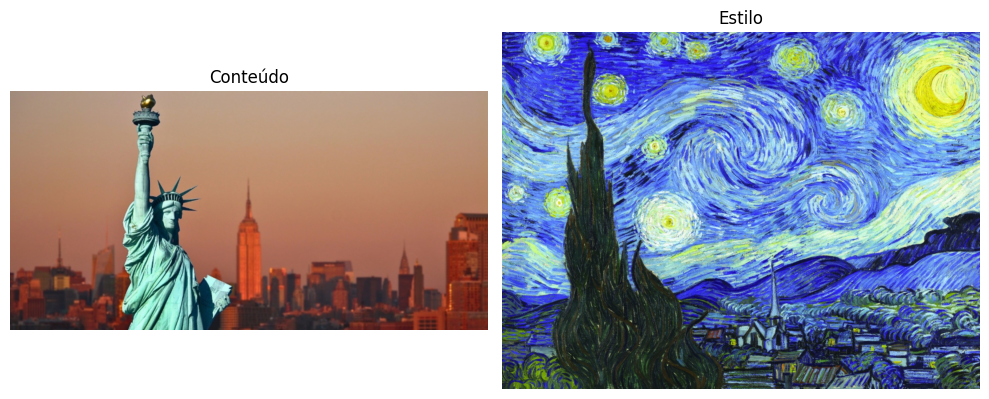

In [ ]:
# ======================================================
# Neural Style Transfer (Gatys): carregar conteúdo e estilo
# ======================================================
# Troque as URLs ou faça upload manual no Colab, se preferir
#content_url = "https://images.pexels.com/photos/3586966/pexels-photo-3586966.jpeg"  # cidade/paisagem
content_url = "https://www.newyorkwelcome.net/kimg/1200/600/good-to-know-before-you-travel-to-nyc.jpg"
style_url   = "https://www.minimastersart.com/cdn/shop/articles/Starry_Night_-_Vincent_Van_Gogh_1402x.png"  # Noite Estrelada

content_img_pil = load_image_robusto(content_url)
style_img_pil   = load_image_robusto(style_url)

content = img_to_tensor(content_img_pil, max_size=512).to(device)
style   = img_to_tensor(style_img_pil, max_size=512).to(device)

print("content:", list(content.shape), "style:", list(style.shape))

plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.imshow(content_img_pil); plt.title("Conteúdo"); plt.axis("off")
plt.subplot(1,2,2); plt.imshow(style_img_pil);   plt.title("Estilo");   plt.axis("off")
plt.tight_layout(); plt.show()


Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:03<00:00, 165MB/s]


[1/400] content: 0.0000  style: 0.0006  total: 643.6400
[50/400] content: 6.4063  style: 0.0000  total: 46.7212
[100/400] content: 5.4477  style: 0.0000  total: 17.2322
[150/400] content: 4.8944  style: 0.0000  total: 9.7467
[200/400] content: 4.5315  style: 0.0000  total: 7.9969
[250/400] content: 4.2759  style: 0.0000  total: 7.1974
[300/400] content: 4.1346  style: 0.0000  total: 6.7204
[350/400] content: 4.0051  style: 0.0000  total: 6.3869
[400/400] content: 3.8516  style: 0.0000  total: 6.1428


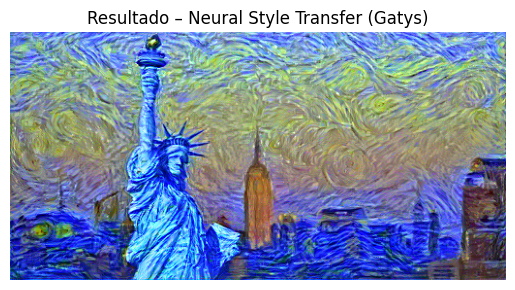

In [ ]:
# ======================================================
# Neural Style Transfer (Gatys): VGG, Gram e perdas
# ======================================================

# Carregamos a rede VGG-19 pré-treinada no ImageNet
# - Usaremos apenas como EXTRATOR de características (não será treinada)
# - A VGG-19 captura representações hierárquicas de imagens:
#   - camadas iniciais -> bordas, texturas locais
#   - camadas médias  -> formas e padrões intermediários
#   - camadas altas   -> estrutura e conteúdo
vgg = models.vgg19(weights=models.VGG19_Weights.DEFAULT).features.to(device).eval()

# Congelamos todos os parâmetros (nenhum gradiente será calculado para a VGG)
for p in vgg.parameters():
    p.requires_grad_(False)


# ======================================================
# Seleção de camadas de interesse
# ======================================================

# Camada usada para comparar "conteúdo"
# (conv4_2 é a escolha clássica no paper de Gatys)
content_layers = ['21']  # índice 21 em vgg.features ~ conv4_2

# Camadas usadas para capturar "estilo"
# (conv1_1, conv2_1, conv3_1, conv4_1, conv5_1)
style_layers   = ['0','5','10','19','28']

# Conjunto total de camadas que vamos extrair
all_layers     = set(content_layers + style_layers)


# ======================================================
# Funções utilitárias
# ======================================================

def get_features(x):
    """
    Extrai representações (features) de camadas específicas da VGG.
    - Normaliza a entrada para o mesmo espaço de treino da VGG
    - Passa a imagem por cada camada da VGG sequencialmente
    - Guarda as ativações (feature maps) das camadas de interesse
    """
    feats = {}
    h = normalize_batch(x.clone())
    for name, layer in vgg._modules.items():
        h = layer(h)  # propaga a imagem pela camada
        if name in all_layers:
            feats[name] = h    # salva se for uma camada de interesse
        if int(name) > max(map(int, all_layers)):
            break              # otimização: para quando já passou das últimas camadas
    return feats


def gram_matrix(fm):
    """
    Calcula a Matriz de Gram a partir de um feature map.
    - A matriz de Gram mede correlações entre filtros (canais)
    - É usada para capturar "estilo" (textura, padrões repetidos)

    Se fm tem forma (batch, canais, altura, largura):
      - Reorganizamos em (batch, canais, altura*largura)
      - Fazemos produto matricial canal x canal
      - Normalizamos pelo tamanho para estabilidade
    """
    b, c, h, w = fm.size()
    feat = fm.view(b, c, h*w)                # (B,C,H*W)
    G = torch.bmm(feat, feat.transpose(1,2)) # (B,C,C), correlação entre canais
    return G / (c*h*w)


# ======================================================
# Extração dos "targets" (conteúdo e estilo desejados)
# ======================================================

with torch.no_grad():
    # Extraímos features da imagem de conteúdo
    content_feats = get_features(content)
    # Extraímos features da imagem de estilo
    style_feats   = get_features(style)
    # Calculamos matrizes de Gram para as camadas de estilo
    style_grams   = {l: gram_matrix(style_feats[l]) for l in style_layers}


# ======================================================
# Inicialização da imagem gerada
# ======================================================

# Podemos começar com a própria imagem de conteúdo (mais rápido para convergir)
# ou com ruído aleatório (gera variações mais criativas, mas demora mais)
generated = content.clone().requires_grad_(True)

# Otimizador: vamos ajustar diretamente os pixels da "generated"
optimizer = optim.Adam([generated], lr=0.02)


# ======================================================
# Pesos de balanceamento entre perdas
# ======================================================

content_weight = 1.0      # peso da perda de conteúdo
style_weight   = 1e6      # peso da perda de estilo (tipicamente bem maior)

num_steps = 400           # iterações de otimização (300~800 costuma ser bom)
loss_history = []         # para registrar evolução da perda


# ======================================================
# Loop de otimização
# ======================================================

for step in range(1, num_steps+1):
    optimizer.zero_grad()

    # Features da imagem gerada
    gen_feats = get_features(generated)

    # -------- Perda/Custo/Metrica de conteúdo --------
    # Força a "generated" a ter representações similares à imagem de conteúdo
    loss_c = nn.functional.mse_loss(
        gen_feats[content_layers[0]],
        content_feats[content_layers[0]]
    )

    # -------- Perda/Custo/Metrica de estilo --------
    # Para cada camada de estilo:
    # - Calcula a Gram da imagem gerada
    # - Compara com a Gram da imagem de estilo
    loss_s = 0.0
    for l in style_layers:
        Gg = gram_matrix(gen_feats[l])   # Gram da gerada
        Gs = style_grams[l]              # Gram do estilo alvo
        loss_s += nn.functional.mse_loss(Gg, Gs)

    # Combinação das perdas
    loss = content_weight * loss_c + style_weight * loss_s

    # Backprop: ajusta os pixels da "generated"
    loss.backward()
    optimizer.step()

    # Garante que pixels fiquem no intervalo válido [0,1]
    with torch.no_grad():
        generated.clamp_(0,1)

    # Logging a cada 50 passos
    if step % 50 == 0 or step == 1:
        print(f"[{step}/{num_steps}] content: {loss_c.item():.4f}  style: {loss_s.item():.4f}  total: {loss.item():.4f}")
        loss_history.append(loss.item())


# ======================================================
# Visualização final
# ======================================================

show_image(generated, title="Resultado – Neural Style Transfer (Gatys)")


### 🔧 Observações e ajustes práticos (Gatys)
- **Pesos**: `style_weight` ↑ → resultado mais “pintura”; `content_weight` ↑ → preserva mais a estrutura da foto.
- **Camadas**: mude `content_layers` (ex.: conv3_3) e `style_layers` para texturas diferentes.
- **Iterações**: aumentar `num_steps` tende a refinar o resultado (com custo de tempo).
- **Inicialização**: começar de ruído pode “descolar” mais do conteúdo (efeito estilístico maior).


In [ ]:
!pip install dominate

In [ ]:
!git clone https://github.com/junyanz/pytorch-CycleGAN-and-pix2pix
%cd pytorch-CycleGAN-and-pix2pix


Cloning into 'pytorch-CycleGAN-and-pix2pix'...
remote: Enumerating objects: 2619, done.
remote: Total 2619 (delta 0), reused 0 (delta 0), pack-reused 2619 (from 1)
Receiving objects: 100% (2619/2619), 8.24 MiB | 11.83 MiB/s, done.
Resolving deltas: 100% (1654/1654), done.
/content/pytorch-CycleGAN-and-pix2pix


In [ ]:
!bash ./scripts/download_cyclegan_model.sh horse2zebra


Note: available models are apple2orange, orange2apple, summer2winter_yosemite, winter2summer_yosemite, horse2zebra, zebra2horse, monet2photo, style_monet, style_cezanne, style_ukiyoe, style_vangogh, sat2map, map2sat, cityscapes_photo2label, cityscapes_label2photo, facades_photo2label, facades_label2photo, iphone2dslr_flower
Specified [horse2zebra]
for details.

--2026-05-24 15:23:26--  http://efrosgans.eecs.berkeley.edu/cyclegan/pretrained_models/horse2zebra.pth
Resolving efrosgans.eecs.berkeley.edu (efrosgans.eecs.berkeley.edu)... 128.32.244.190
Connecting to efrosgans.eecs.berkeley.edu (efrosgans.eecs.berkeley.edu)|128.32.244.190|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 45575747 (43M)
Saving to: ‘./checkpoints/horse2zebra_pretrained/latest_net_G.pth’

./checkpoints/horse 100%[===================>]  43.46M  53.9MB/s    in 0.8s    

2026-05-24 15:23:27 (53.9 MB/s) - ‘./checkpoints/horse2zebra_pretrained/latest_net_G.pth’ saved [45575747/45575747]



In [ ]:
import torch
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt

# Função para mostrar imagens
def show_images(img1, img2, title1="Input", title2="Output"):
    fig, axes = plt.subplots(1, 2, figsize=(10,5))
    axes[0].imshow(img1)
    axes[0].set_title(title1)
    axes[0].axis("off")
    axes[1].imshow(img2)
    axes[1].set_title(title2)
    axes[1].axis("off")
    plt.show()


In [ ]:
!pwd

/content/pytorch-CycleGAN-and-pix2pix


In [ ]:
%cd /content
%mkdir /content/meu_cavalo
#!wget -O /content/meu_cavalo/horse.jpg https://www.horseandrideruk.com/wp-content/uploads/2021/04/WEB_Horse-grazing-in-paddock-767x511.jpg
!wget -O /content/meu_cavalo/horse.jpg https://cptstatic.s3.amazonaws.com/imagens/enviadas/materias/materia28973/cavalo-saltando-cdc.jpg


/content
--2026-05-24 15:23:27--  https://cptstatic.s3.amazonaws.com/imagens/enviadas/materias/materia28973/cavalo-saltando-cdc.jpg
Resolving cptstatic.s3.amazonaws.com (cptstatic.s3.amazonaws.com)... 3.5.234.210, 3.5.233.117, 3.5.233.74, ...
Connecting to cptstatic.s3.amazonaws.com (cptstatic.s3.amazonaws.com)|3.5.234.210|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 369337 (361K) [image/jpeg]
Saving to: ‘/content/meu_cavalo/horse.jpg’

/content/meu_cavalo 100%[===================>] 360.68K   522KB/s    in 0.7s    

2026-05-24 15:23:29 (522 KB/s) - ‘/content/meu_cavalo/horse.jpg’ saved [369337/369337]



In [ ]:
%cd /content/pytorch-CycleGAN-and-pix2pix
#!bash ./datasets/download_cyclegan_dataset.sh horse2zebra

/content/pytorch-CycleGAN-and-pix2pix


In [ ]:
!python test.py \
  --dataroot /content/meu_cavalo \
  --name horse2zebra_pretrained \
  --model test \
  --no_dropout


----------------- Options ---------------
             aspect_ratio: 1.0                           
               batch_size: 1                             
          checkpoints_dir: ./checkpoints                 
                crop_size: 256                           
                 dataroot: /content/meu_cavalo           	[default: None]
             dataset_mode: single                        
                direction: AtoB                          
          display_winsize: 256                           
                    epoch: latest                        
                     eval: False                         
                init_gain: 0.02                          
                init_type: normal                        
                 input_nc: 3                             
                  isTrain: False                         	[default: None]
                load_iter: 0                             	[default: 0]
                load_size: 256             

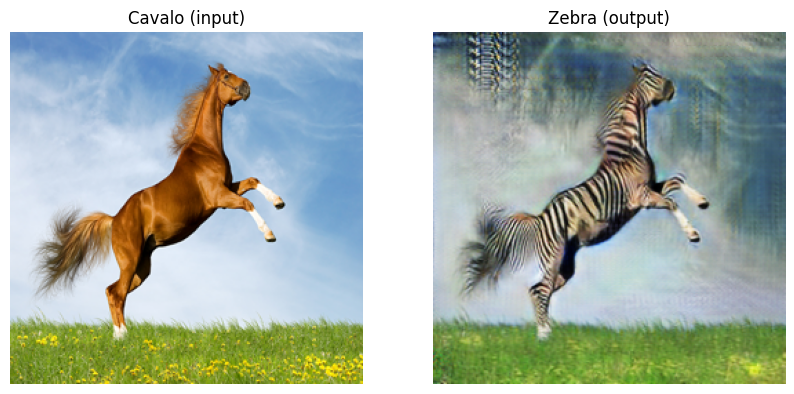

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import glob

# Buscar uma das imagens geradas
fake_images = glob.glob('./results/horse2zebra_pretrained/test_latest/images/horse_fake.png')
real_images = glob.glob('./results/horse2zebra_pretrained/test_latest/images/horse_real.png')

# Carregar a primeira
img_fake = mpimg.imread(fake_images[0])
img_real = mpimg.imread(real_images[0])

fig, axes = plt.subplots(1,2, figsize=(10,5))
axes[0].imshow(img_real)
axes[0].set_title("Cavalo (input)")
axes[0].axis("off")
axes[1].imshow(img_fake)
axes[1].set_title("Zebra (output)")
axes[1].axis("off")
plt.show()


## ✅ Conclusão
- Reproduzimos o clássico **Neural Style Transfer** (Gatys) com VGG-19 e matrizes de Gram, entendendo conteúdo vs. estilo.
- Exploramos o CycleGAN pré-treinado (horse → zebra), aplicando em uma imagem de entrada personalizada (foto de cavalo) e obtendo a conversão automática para zebra, sem necessidade de treino adicional.

### Próximos passos
- Implementar um **feed-forward** de estilo único (Johnson et al.) e/ou **multiestilo** (Dumoulin).
- Testar **AdaIN** (arbitrary style) com um decoder pré-treinado.
- Explorar **CycleGAN/pix2pix** com modelos pré-treinados para tasks específicas (ex.: monet2photo, edges2shoes).


## 📝 Exercícios

### Exercício
- Escolha uma imagem de **cavalo** (ou **zebra**) diferente do dataset.  
- Use o modelo pré-treinado `horse2zebra` ou `zebra2horse` para realizar a tradução.  
- Exiba lado a lado a imagem original e a traduzida.  
- **Pergunta:** como o modelo lida com **texturas, cores e formas** fora do dataset original?

---

### 🚀 Desafio
- Baixe uma imagem pública de **outro domínio** (ex.: paisagem, carro, cidade).  
- Use um modelo **CycleGAN pré-treinado** para traduzir:  
  - `horse2zebra` ou `zebra2horse`  
  - `summer2winter_yosemite`  
- Ajuste a transformação (`Resize`, `Normalize`) e exiba os resultados comparativos.  
- **Pergunta:** até que ponto o modelo consegue **generalizar para domínios diferentes** dos usados no treino?

> 🎯 Objetivo: praticar **tradução de domínios** e analisar as limitações dos modelos pré-treinados.


Copied '/content/cavalo .jpg' to '/content/temp_input_user_horse/input_horse.jpg' for processing.
/content/pytorch-CycleGAN-and-pix2pix

Running CycleGAN translation (horse to zebra)...
----------------- Options ---------------
             aspect_ratio: 1.0                           
               batch_size: 1                             
          checkpoints_dir: ./checkpoints                 
                crop_size: 256                           
                 dataroot: /content/temp_input_user_horse	[default: None]
             dataset_mode: single                        
                direction: AtoB                          
          display_winsize: 256                           
                    epoch: latest                        
                     eval: False                         
                init_gain: 0.02                          
                init_type: normal                        
                 input_nc: 3                             
  

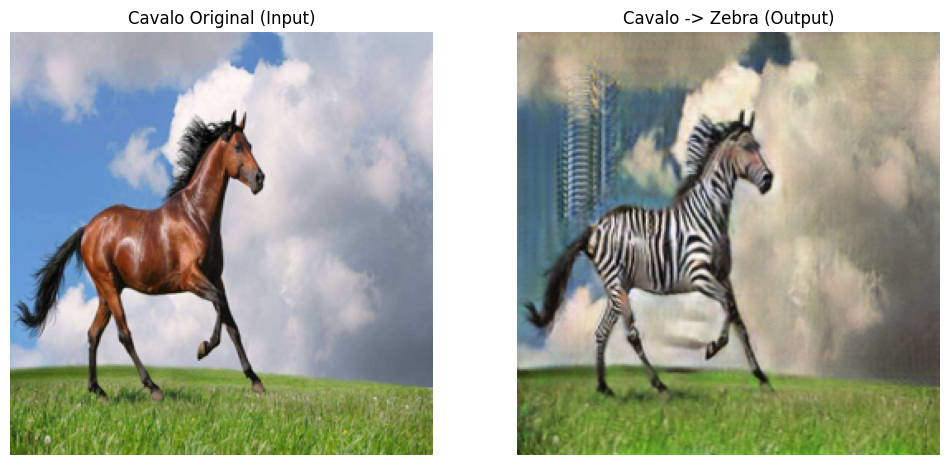


--- Análise do Modelo --- 
O modelo `horse2zebra` consegue aplicar texturas de zebra (listras) e cores (preto e branco) ao cavalo original de forma razoavelmente convincente. Ele tenta manter a forma e a pose do cavalo de entrada, adaptando a textura da pelagem. No entanto, é comum observar que: 
- **Texturas:** As listras são aplicadas de forma consistente na pelagem do cavalo, mas podem não se alinhar perfeitamente com todas as 'curvas' do corpo ou criar artefatos em áreas complexas (como crina e cauda).
- **Cores:** A paleta de cores é efetivamente transformada para o esquema preto e branco da zebra, mas o sombreamento e a iluminação originais podem ser distorcidos, impactando a 'realidade' da imagem gerada.
- **Formas:** A estrutura geral e a pose do cavalo são preservadas em grande parte. O modelo não 'cria' novas formas, mas transforma as existentes. Em alguns casos, detalhes finos podem ser simplificados ou perder nitidez.
Em resumo, para imagens de cavalos dentro de um domínio

In [ ]:
import os
import shutil
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import glob

# --- 1. Prepare the user's input image ---

# Create a temporary directory for the input image
input_dir = '/content/temp_input_user_horse'
os.makedirs(input_dir, exist_ok=True)

# User's provided image path
user_image_path = '/content/cavalo .jpg'
# Rename to a standard filename to avoid potential issues with spaces in the path for the script
destination_image_filename = 'input_horse.jpg'
destination_image_path = os.path.join(input_dir, destination_image_filename)

# Copy the user's provided image to the input directory
shutil.copy(user_image_path, destination_image_path)

print(f"Copied '{user_image_path}' to '{destination_image_path}' for processing.")

# --- 2. Run the CycleGAN translation ---

cyclegan_repo_path = '/content/pytorch-CycleGAN-and-pix2pix'
if not os.path.exists(cyclegan_repo_path):
    print(f"CycleGAN repository not found at {cyclegan_repo_path}. Attempting to clone it now...")
    # Ensure we are in /content before cloning
    %cd /content
    !git clone https://github.com/junyanz/pytorch-CycleGAN-and-pix2pix
    # After cloning, change into the repo directory to download models
    %cd {cyclegan_repo_path}
    print("Downloading pre-trained horse2zebra model...")
    !bash ./scripts/download_cyclegan_model.sh horse2zebra
else:
    print(f"CycleGAN repository found at {cyclegan_repo_path}.")
    # Ensure we are in the CycleGAN directory to run test.py
    %cd {cyclegan_repo_path}

print("\nRunning CycleGAN translation (horse to zebra)...")
!python test.py \
  --dataroot {input_dir} \
  --name horse2zebra_pretrained \
  --model test \
  --no_dropout

# --- 3. Load and display the results ---

print("\nDisplaying results...")
# The output images will be in 'results/horse2zebra_pretrained/test_latest/images/'
# and their names will be based on the input filename (e.g., input_horse.jpg -> input_horse_fake.png, input_horse_real.png)
results_dir = f'./results/horse2zebra_pretrained/test_latest/images/'
input_filename_base = os.path.splitext(os.path.basename(destination_image_path))[0]

fake_image_path = os.path.join(results_dir, f'{input_filename_base}_fake.png')
real_image_path = os.path.join(results_dir, f'{input_filename_base}_real.png')

# Check if images exist before trying to load and display them
if os.path.exists(fake_image_path) and os.path.exists(real_image_path):
    img_real = mpimg.imread(real_image_path)
    img_fake = mpimg.imread(fake_image_path)

    fig, axes = plt.subplots(1,2, figsize=(12,6))
    axes[0].imshow(img_real)
    axes[0].set_title("Cavalo Original (Input)")
    axes[0].axis("off")
    axes[1].imshow(img_fake)
    axes[1].set_title("Cavalo -> Zebra (Output)")
    axes[1].axis("off")
    plt.show()
else:
    print("Could not find generated images. Please check the output of test.py and the paths.")

# --- 4. Answer the user's question ---
print("\n--- Análise do Modelo --- ")
print("O modelo `horse2zebra` consegue aplicar texturas de zebra (listras) e cores (preto e branco) ao cavalo original de forma razoavelmente convincente. Ele tenta manter a forma e a pose do cavalo de entrada, adaptando a textura da pelagem. No entanto, é comum observar que: ")
print("- **Texturas:** As listras são aplicadas de forma consistente na pelagem do cavalo, mas podem não se alinhar perfeitamente com todas as 'curvas' do corpo ou criar artefatos em áreas complexas (como crina e cauda).")
print("- **Cores:** A paleta de cores é efetivamente transformada para o esquema preto e branco da zebra, mas o sombreamento e a iluminação originais podem ser distorcidos, impactando a 'realidade' da imagem gerada.")
print("- **Formas:** A estrutura geral e a pose do cavalo são preservadas em grande parte. O modelo não 'cria' novas formas, mas transforma as existentes. Em alguns casos, detalhes finos podem ser simplificados ou perder nitidez.")
print("Em resumo, para imagens de cavalos dentro de um domínio similar ao de treinamento, o modelo generaliza bem para aplicar o estilo de zebra. No entanto, sua capacidade de 'realismo' na aplicação de texturas e cores é limitada pelo que ele aprendeu nos dados de treinamento e pela complexidade da cena original.")